***.loc*** ==> Used in places where we use labels to access rows and columns from either a dataframe or a table.

***.iloc*** ==> Used in places where we use indexes to access rows and columns from either a dataframe or a table.

***apply()*** ==> Used when there is need of conditional cases to be performed on column.
These are usually slow as they are applied row wise(one-by-one)

***vectorized*** ==> Used when there is a need for instant math application on columns, this is faster as it handles operations using Single instruction Multipe data principle making it to be applied simultaneously.


In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
print(f"Shape: " + str(df.shape))

df = pd.DataFrame(df)

Shape: (891, 12)


In [8]:
for col in df.columns:
  print(f"{col} : {df[col].dtypes}")

PassengerId : int64
Survived : int64
Pclass : int64
Name : object
Sex : object
Age : float64
SibSp : int64
Parch : int64
Ticket : object
Fare : float64
Cabin : object
Embarked : object


In [9]:
for col in df.columns:
  print(f"{col} :==> {df[col].isna().sum()}")

PassengerId :==> 0
Survived :==> 0
Pclass :==> 0
Name :==> 0
Sex :==> 0
Age :==> 177
SibSp :==> 0
Parch :==> 0
Ticket :==> 0
Fare :==> 0
Cabin :==> 687
Embarked :==> 2


In [10]:
for col in df.columns:
  print(f"{col} :==> {df[col].nunique()}")

PassengerId :==> 891
Survived :==> 2
Pclass :==> 3
Name :==> 891
Sex :==> 2
Age :==> 88
SibSp :==> 7
Parch :==> 7
Ticket :==> 681
Fare :==> 248
Cabin :==> 147
Embarked :==> 3


In [11]:
survived = df['Survived'].mean()
survived_gender = df.groupby('Sex')["Survived"].mean()
survived_class = df.groupby('Pclass')["Survived"].mean()
survived_age_mean = df.groupby('Survived')["Age"].mean()
survived_embarked_max = df.groupby('Embarked')["Survived"].mean().idxmax()

df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 60, 100], labels=["Child", "Teen", "Adult", "Elder"])
survived_age_max = df.groupby('AgeGroup', observed= False)['Survived'].mean().idxmax()

print(f"Survival rate overall : {survived}")
print(f"Survival rate by gender : {survived_gender}")
print(f"Survival rate by passenger class : {survived_class}")
print(f"Average age of survivors vs non-survivors : {survived_age_mean}")
print(f"Survival rate by passenger class : {survived_embarked_max}")
print(f"Age group with highest survival rate : {survived_age_max}")


Survival rate overall : 0.3838383838383838
Survival rate by gender : Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Survival rate by passenger class : Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Average age of survivors vs non-survivors : Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64
Survival rate by passenger class : C
Age group with highest survival rate : Child


In [12]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["Family"] = pd.cut(df["FamilySize"], bins=[0, 1, 4, 10], labels=["Alone", "Small Family", "Large Family"])
survived_family = df.groupby("Family")["Survived"].mean()
print(f"Survival rate by family size : {survived_family}")

Survival rate by family size : Family
Alone           0.303538
Small Family    0.578767
Large Family    0.181818
Name: Survived, dtype: float64


/tmp/ipykernel_6154/440170622.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survived_family = df.groupby("Family")["Survived"].mean()


/tmp/ipykernel_6154/1968179043.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survived_family = df.groupby("Family")["Survived"].sum()


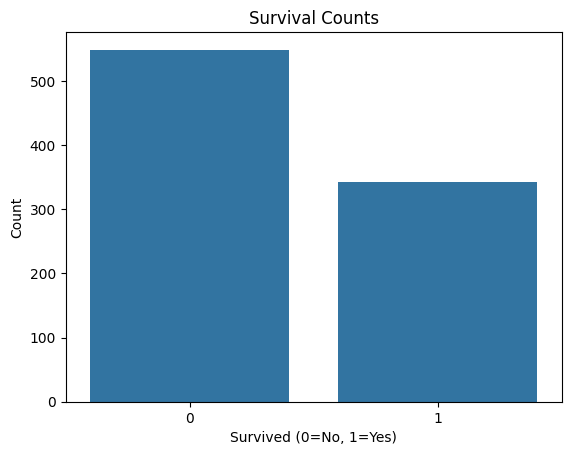

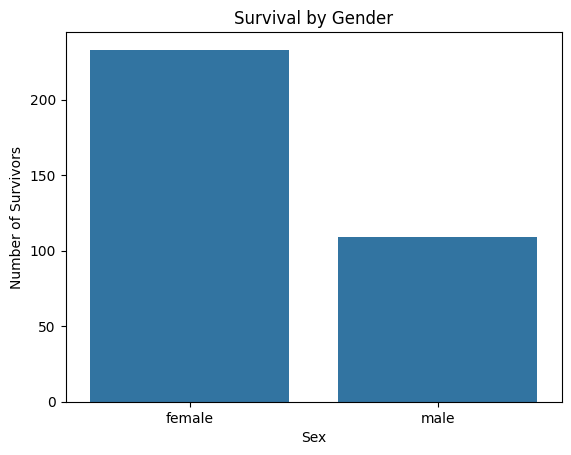

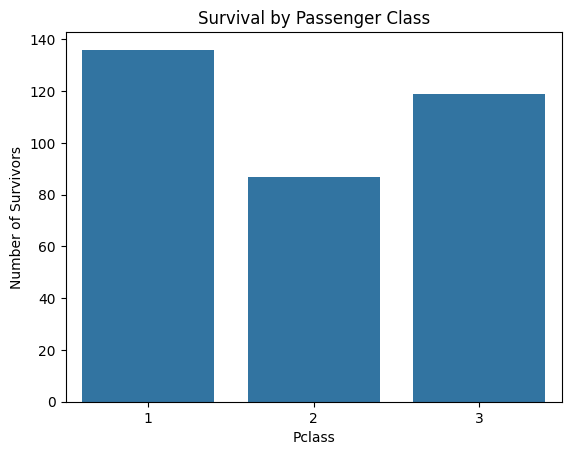

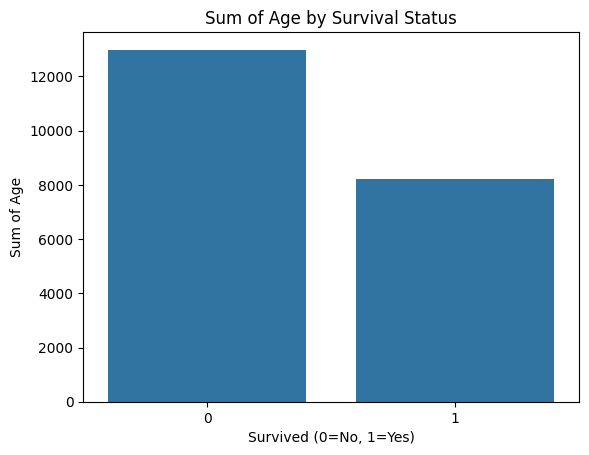

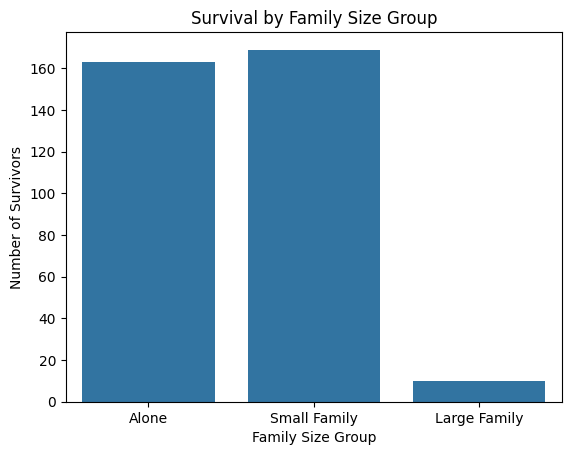

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


# Corrected: Use value_counts to get counts of each survival status for plotting
survived_counts = df['Survived'].value_counts()
survived_gender = df.groupby('Sex')["Survived"].sum()
survived_class = df.groupby('Pclass')["Survived"].sum()
survived_age_dist = df.groupby('Survived')["Age"].sum()
survived_family = df.groupby("Family")["Survived"].sum()

# Corrected: Plotting survived_counts as a bar plot
sns.barplot(x=survived_counts.index, y=survived_counts.values).set(title='Survival Counts', xlabel='Survived (0=No, 1=Yes)', ylabel='Count')
plt.show()
print("")
sns.barplot(survived_gender).set(title='Survival by Gender', xlabel='Sex', ylabel='Number of Survivors')
plt.show()

sns.barplot(survived_class).set(title='Survival by Passenger Class', xlabel='Pclass', ylabel='Number of Survivors')
plt.show()

sns.barplot(survived_age_dist).set(title='Sum of Age by Survival Status', xlabel='Survived (0=No, 1=Yes)', ylabel='Sum of Age')
plt.show()

sns.barplot(survived_family).set(title='Survival by Family Size Group', xlabel='Family Size Group', ylabel='Number of Survivors')
plt.show()

In [14]:

df['Age'].fillna(df['Age'].median(), inplace = True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)
df

/tmp/ipykernel_6154/2694858809.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace = True)
/tmp/ipykernel_6154/2694858809.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,FamilySize,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult,2,Small Family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,2,Small Family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult,1,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,2,Small Family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult,1,Alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Adult,1,Alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Adult,1,Alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S,NaN,4,Small Family
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Adult,1,Alone


In [15]:
df.drop('Name',axis = 1, inplace = True)
df.drop('Ticket', axis = 1, inplace = True)
df.drop('Cabin', axis = 1, inplace = True)

In [16]:
df['AgeGroup'] = df['AgeGroup'].fillna(df['AgeGroup'].mode()[0])
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,FamilySize,Family
0,1,0,3,male,22.0,1,0,7.2500,S,Adult,2,Small Family
1,2,1,1,female,38.0,1,0,71.2833,C,Adult,2,Small Family
2,3,1,3,female,26.0,0,0,7.9250,S,Adult,1,Alone
3,4,1,1,female,35.0,1,0,53.1000,S,Adult,2,Small Family
4,5,0,3,male,35.0,0,0,8.0500,S,Adult,1,Alone
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S,Adult,1,Alone
887,888,1,1,female,19.0,0,0,30.0000,S,Adult,1,Alone
888,889,0,3,female,28.0,1,2,23.4500,S,Adult,4,Small Family
889,890,1,1,male,26.0,0,0,30.0000,C,Adult,1,Alone


In [17]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=['object', 'category']).columns
le = LabelEncoder()

print(cat_cols)
for col in cat_cols:
  df[col] = le.fit_transform(df[col])

df

Index(['Sex', 'Embarked', 'AgeGroup', 'Family'], dtype='object')


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,FamilySize,Family
0,1,0,3,1,22.0,1,0,7.2500,2,0,2,2
1,2,1,1,0,38.0,1,0,71.2833,0,0,2,2
2,3,1,3,0,26.0,0,0,7.9250,2,0,1,0
3,4,1,1,0,35.0,1,0,53.1000,2,0,2,2
4,5,0,3,1,35.0,0,0,8.0500,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.0,0,0,13.0000,2,0,1,0
887,888,1,1,0,19.0,0,0,30.0000,2,0,1,0
888,889,0,3,0,28.0,1,2,23.4500,2,0,4,2
889,890,1,1,1,26.0,0,0,30.0000,0,0,1,0


In [18]:
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include=['float64']).columns
print(num_cols)
scaler = StandardScaler()


df[num_cols] = scaler.fit_transform(df[num_cols])

df

Index(['Age', 'Fare'], dtype='object')


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,FamilySize,Family
0,1,0,3,1,-0.565736,1,0,-0.502445,2,0,2,2
1,2,1,1,0,0.663861,1,0,0.786845,0,0,2,2
2,3,1,3,0,-0.258337,0,0,-0.488854,2,0,1,0
3,4,1,1,0,0.433312,1,0,0.420730,2,0,2,2
4,5,0,3,1,0.433312,0,0,-0.486337,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,-0.181487,0,0,-0.386671,2,0,1,0
887,888,1,1,0,-0.796286,0,0,-0.044381,2,0,1,0
888,889,0,3,0,-0.104637,1,2,-0.176263,2,0,4,2
889,890,1,1,1,-0.258337,0,0,-0.044381,0,0,1,0


In [19]:
test_df = pd.read_csv('test.csv')
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


### Cleaning and Preparing the Test Data

We need to apply the same cleaning and feature engineering steps to the `test_df` as we did for the `df` (training data) to ensure consistency. This includes:

1.  **Handling Missing Values**: Fill missing 'Age' with the median, 'Embarked' with the mode, and 'Fare' with its median (as 'Fare' can have missing values in the test set).
2.  **Creating New Features**: Recreate 'AgeGroup', 'FamilySize', and 'Family' columns.
3.  **Dropping Columns**: Remove 'Name', 'Ticket', and 'Cabin'.
4.  **Label Encoding**: Apply `LabelEncoder` to categorical columns.
5.  **Standard Scaling**: Apply `StandardScaler` to numerical columns.

In [20]:
# Handle missing values in test_df
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)
test_df['Embarked'].fillna(test_df['Embarked'].mode()[0], inplace=True)
# Fare might have missing values in the test set, so we fill it with the median
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

# Create new features in test_df
test_df['AgeGroup'] = pd.cut(test_df['Age'], bins=[0, 12, 18, 60, 100], labels=["Child", "Teen", "Adult", "Elder"])
test_df['FamilySize'] = test_df["SibSp"] + test_df["Parch"] + 1
test_df['Family'] = pd.cut(test_df["FamilySize"], bins=[0, 1, 4, 10], labels=["Alone", "Small Family", "Large Family"])

# Fill any potential NaN in 'AgeGroup' in test_df (can happen if an age falls outside the bins)
test_df['AgeGroup'].fillna(test_df['AgeGroup'].mode()[0], inplace=True)

# Drop unnecessary columns from test_df
test_df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

display(test_df.head())

/tmp/ipykernel_6154/1960048291.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Age'].fillna(test_df['Age'].median(), inplace=True)
/tmp/ipykernel_6154/1960048291.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,FamilySize,Family
0,892,3,male,34.5,0,0,7.8292,Q,Adult,1,Alone
1,893,3,female,47.0,1,0,7.0000,S,Adult,2,Small Family
2,894,2,male,62.0,0,0,9.6875,Q,Elder,1,Alone
3,895,3,male,27.0,0,0,8.6625,S,Adult,1,Alone
4,896,3,female,22.0,1,1,12.2875,S,Adult,3,Small Family


In [21]:
# Apply Label Encoding to categorical columns in test_df
# Re-initialize LabelEncoder for each column for simplicity, assuming categories are consistent
cat_cols_test = test_df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols_test:
  le = LabelEncoder() # Re-instantiate for each column to avoid issues with previous fits
  test_df[col] = le.fit_transform(test_df[col])

# Apply Standard Scaling to numerical columns in test_df using the scaler fitted on the training data
# num_cols and scaler were defined and fitted on the training data previously
test_df[num_cols] = scaler.transform(test_df[num_cols])

display(test_df.head())

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,FamilySize,Family
0,892,3,1,0.394887,0,0,-0.490783,1,0,1,0
1,893,3,0,1.355510,1,0,-0.507479,2,0,2,2
2,894,2,1,2.508257,0,0,-0.453367,1,2,1,0
3,895,3,1,-0.181487,0,0,-0.474005,2,0,1,0
4,896,3,0,-0.565736,1,1,-0.401017,2,0,3,2


The `test_df` is now cleaned and transformed, matching the structure of the training `df`.

In [22]:
X_train_train = df.drop('Survived', axis = 1)
y_train_train = df['Survived']

X_test = test_df

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


X_train, X_val, y_train, y_val = train_test_split(X_train_train, y_train_train, test_size=0.2, random_state=42)

model1 = LogisticRegression()
model2 = RandomForestClassifier()

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

y_pred1 = model1.predict(X_val)
y_pred2 = model2.predict(X_val)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model Performance Evaluation

Now, let's evaluate the performance of the trained `LogisticRegression` and `RandomForestClassifier` models using various metrics on the validation set (`X_val`, `y_val`). We will look at:

*   **Accuracy Score**: The proportion of correctly classified instances.
*   **Classification Report**: Provides precision, recall, f1-score, and support for each class.
*   **Confusion Matrix**: A table showing the number of true positives, true negatives, false positives, and false negatives.


--- Logistic Regression Model Performance ---
Accuracy: 0.8045

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



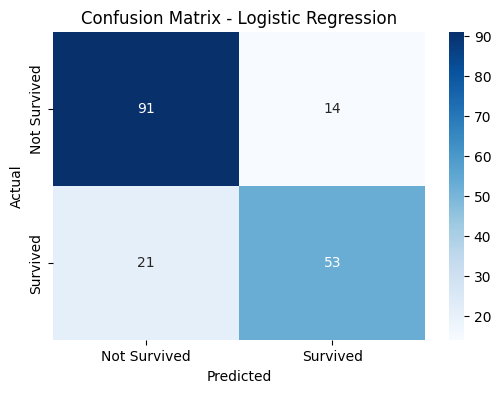


--- Random Forest Classifier Model Performance ---
Accuracy: 0.8380

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86       105
           1       0.82      0.78      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



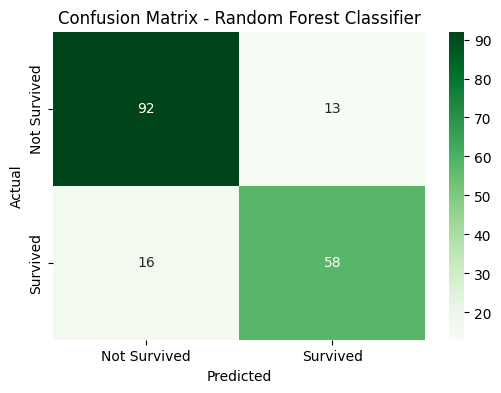

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Evaluate Logistic Regression (model1) ---
print("\n--- Logistic Regression Model Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred1):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred1))

# Confusion Matrix for Logistic Regression
cm1 = confusion_matrix(y_val, y_pred1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Evaluate Random Forest Classifier (model2) ---
print("\n--- Random Forest Classifier Model Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred2):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred2))

# Confusion Matrix for Random Forest Classifier
cm2 = confusion_matrix(y_val, y_pred2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Confusion Matrix Analysis

#### Interpreting the Confusion Matrix:

A confusion matrix provides a detailed breakdown of correct and incorrect predictions made by a classification model. For our 'Survived' prediction task, where `0` means 'Did Not Survive' and `1` means 'Survived', the terms are:

*   **True Negative (TN)**: The model correctly predicted the passenger did not survive (Actual: 0, Predicted: 0).
*   **False Positive (FP)**: The model incorrectly predicted the passenger survived (Actual: 0, Predicted: 1). This is also known as a Type I error.
*   **False Negative (FN)**: The model incorrectly predicted the passenger did not survive (Actual: 1, Predicted: 0). This is also known as a Type II error.
*   **True Positive (TP)**: The model correctly predicted the passenger survived (Actual: 1, Predicted: 1).

By examining the values in these matrices, we can understand the specific types of errors each model is making and assess their strengths and weaknesses beyond just overall accuracy.

### Feature Contribution Analysis using SHAP

To understand which features contribute most to the models' predictions and in what direction, we can use SHAP (SHapley Additive exPlanations) values. SHAP values help us to explain the prediction of an instance by computing the contribution of each feature to the prediction. They connect game theory with local explanations, assigning each feature an importance value for a particular prediction.

First, we need to install the `shap` library.


--- SHAP Summary Plot for Logistic Regression ---


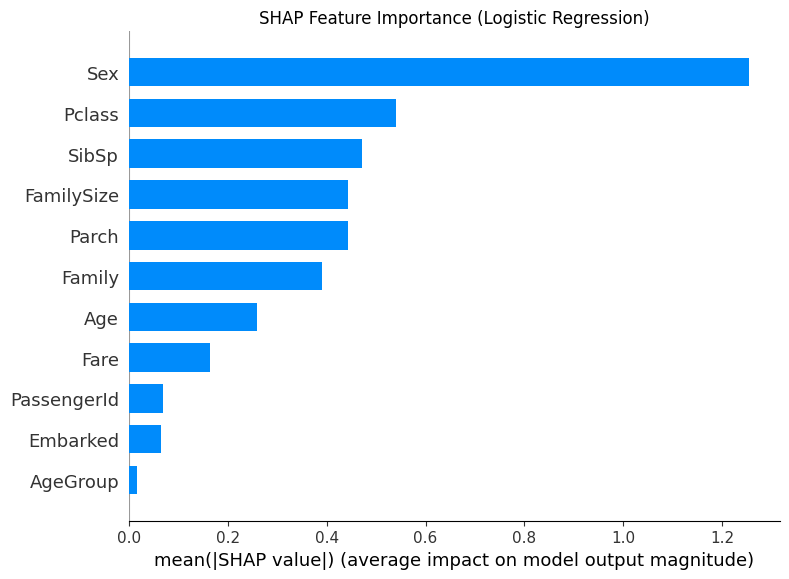

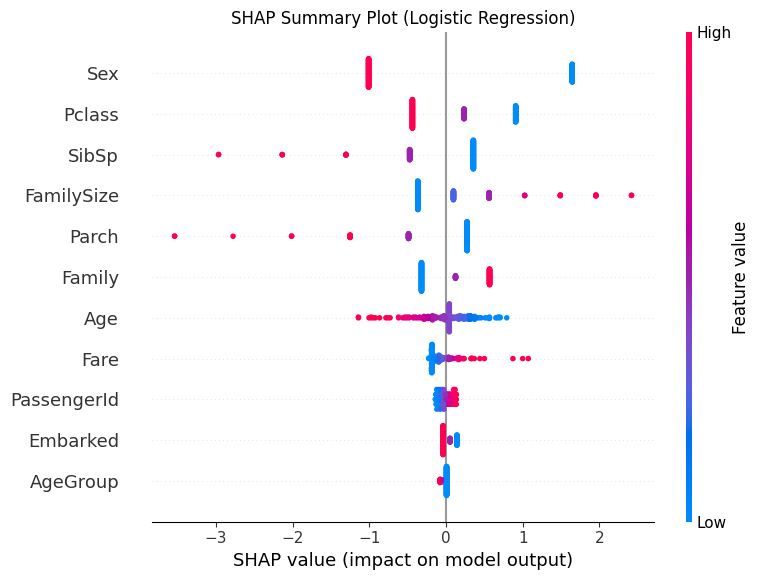


--- SHAP Summary Plot for Random Forest Classifier ---


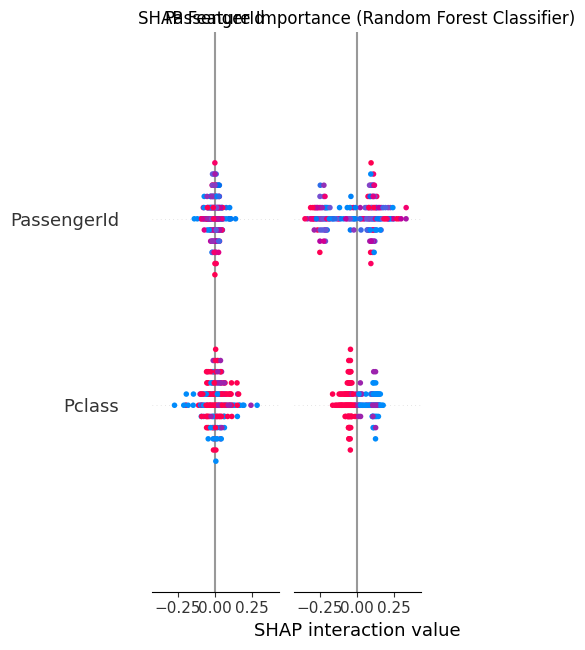

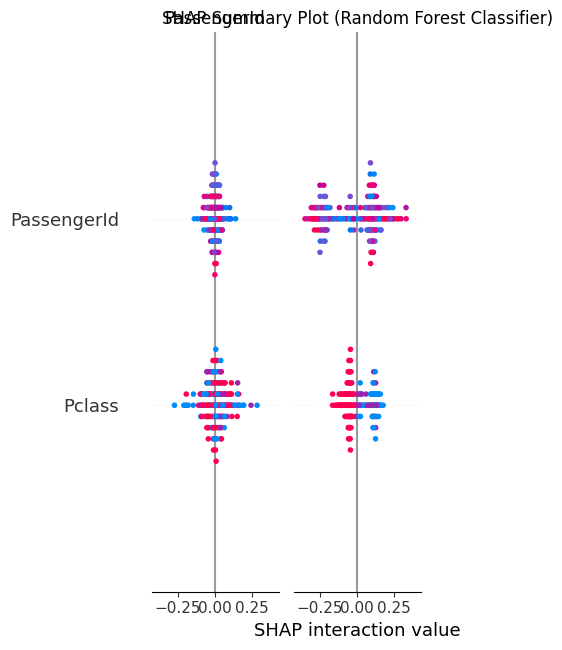

In [26]:
# Install the shap library
%pip install shap

import shap

shap.initjs()

explainer1 = shap.LinearExplainer(model1, X_train)
shap_values1 = explainer1.shap_values(X_val)

print("\n--- SHAP Summary Plot for Logistic Regression ---")
shap.summary_plot(shap_values1, X_val, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Logistic Regression)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values1, X_val, show=False)
plt.title('SHAP Summary Plot (Logistic Regression)')
plt.tight_layout()
plt.show()

explainer2 = shap.TreeExplainer(model2)
shap_values2 = explainer2.shap_values(X_val)

if isinstance(shap_values2, list):
    shap_values2_positive_class = shap_values2[1]
else:
    shap_values2_positive_class = shap_values2

print("\n--- SHAP Summary Plot for Random Forest Classifier ---")
shap.summary_plot(shap_values2_positive_class, X_val, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Random Forest Classifier)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values2_positive_class, X_val, show=False)
plt.title('SHAP Summary Plot (Random Forest Classifier)')
plt.tight_layout()
plt.show()

#### Interpreting SHAP Summary Plots:

*   **Bar Plot (`plot_type="bar"`)**: This plot shows the average absolute SHAP value for each feature, providing a global view of feature importance. Features are ranked from most to least important.

*   **Dot Plot (default `plot_type`)**: Each dot represents a single instance in the dataset.
    *   The **position** on the x-axis shows the SHAP value for that feature and instance. A positive SHAP value means the feature pushed the prediction higher, and a negative value means it pushed it lower.
    *   The **color** of the dot indicates the feature's actual value for that instance (red for high, blue for low).
    *   This plot allows us to see not only how important a feature is but also how its value affects the prediction (e.g., higher 'Fare' leads to higher 'Survived' prediction).

# Q1

### What kinds of mistakes does each model make?

Logistic Regression makes more mistake by producing more false negatives and false positives rather than random forest because it tends to miss to find complex relationship like in random forest

# Q2

### Which model would you choose?  Why?

Random Forest.

From the results, Random Forest produces better results.

# Q3

### If the goal was: Never miss a survivor, which metric becomes most important? Why?

Recall is the metrics that is more important in this case which calculates how any survivors were actually predicted correctly from the actual survivors.

# Q1

### How can you tell if a model is overfitting?

A model is overfitting if the training data has a accuracy and the testing dataset has a lower accuracy, which means that the model became more complex by learning intricate details.

# Q2

### Did either of your models overfit? Use evidence.

No, From the observation , either of them have no signs of overfitting.
# Q3

### How would you reduce overfitting?

* Cross Validation
* Class Balancing
* Scaling and Encoding
* Regularization
* Hyperparameter Tuning

# Q1

### Why is accuracy sometimes misleading?

In class imbalanced dataset, accuracy is a deceptive metric because if the model just predicts all of them as majority class, the accuracy would be high automatically, which is why it is misleading.

# Q2

### Suppose your model has: Accuracy = 98% Recall = 15%
###Would you deploy it for fraud detection? Why?

No, I would not because a recall of 15 % means that it only predicted 15% percent of the actual survivors making it a lousy predictor in this case, which will be the same for fraud detection if True Positive is set as Fraud and the opposite effect if TP is set as not fraud because of the accuracy.

# Q3

### Why do we split into train and test sets?

We split dataset to training and testing to make sure that the model trained is actually a better model than some random guessing, more like a verifying process before testing it on real world test cases. More the performance in these, more is the performance in the real world.

#Q4

###Why shouldn't we look at the test set during development?

Looking at the test data during training can cause an unusual bias like overfitting in the model, as well as making the performance of the model unreliable.

# Q5

### If your boss says: "Just maximize accuracy," how would you respond? Assume you're explaining to a non-technical stakeholder.

I would respond with the technical complications that might happen by just increasing the accuracy.
Increasing accuracy might mean the model is overfit and is not ready for real world data, though that might notbe the case all the time, i would explain the possibility of the losses experienced due to it and try to increase the precision and recall of the classification process. The same goes with regression models too, where i will try the approach of minimizing the errors using regularization or something else.
